# DAYTON Energy Consumption — Time-Series Forecasting

**DSAI 302 Capstone — Energy Consumption Forecasting**

This notebook implements a supervised-learning pipeline for hourly energy-load
forecasting on the PJM DAYTON dataset. The structure mirrors the IEEE-format report
so each section here maps directly to a section of the paper.


## 1. Introduction

Accurate short-term load forecasting underpins grid operations, unit commitment, and
demand response. Utilities rely on it to balance generation against demand on an
hourly basis; small percentage improvements in forecast accuracy translate into
substantial operational cost savings.

**Dataset.** DAYTON_hourly.csv contains hourly system load (`DAYTON_MW`) for the
Dayton zone of the PJM Interconnection from 2004-12-31 through 2018-01-02 — about
121k hourly observations.

**Objective.** Build and compare three tree-based regressors — Random Forest,
XGBoost, and LightGBM — for one-hour-ahead load forecasting using only calendar
and lag features. Evaluate on a strictly held-out future window using MAE, MAPE,
RMSE, MSE, and R². Hyperparameters are tuned via `TimeSeriesSplit`-based
cross-validation to avoid the look-ahead leakage that plain K-Fold introduces.


## 2. Data Analysis and Data Preprocess

### 2.1 Setup

In [1]:
# Standard scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
import xgboost as xgb
import lightgbm as lgb

# Reproducibility — set everywhere a seed is accepted
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Print-friendly academic palette (good for IEEE single- and double-column figures)
sns.set_theme(style='whitegrid', context='paper', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

DATA_PATH = 'DAYTON_hourly.csv'
TARGET = 'DAYTON_MW'


### 2.2 Load & Inspect

In [2]:
# Load and parse timestamps. The file is mostly chronological but the very first
# row is out of order (2004-12-31), so we MUST sort before any temporal split or
# lag-feature construction — otherwise train/val/test boundaries are corrupted.
df = pd.read_csv(DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = (
    df.sort_values('Datetime')
      .drop_duplicates(subset='Datetime')
      .reset_index(drop=True)
)
df.head()


,Datetime,DAYTON_MW
0,2004-10-01 01:00:00,1621.0
1,2004-10-01 02:00:00,1536.0
2,2004-10-01 03:00:00,1500.0
3,2004-10-01 04:00:00,1434.0
4,2004-10-01 05:00:00,1489.0


In [3]:
# Basic structure and missingness checks
print('Shape:', df.shape)
print('Date range:', df['Datetime'].min(), '->', df['Datetime'].max())
print('Missing values per column:')
print(df.isna().sum())
print('Duplicate timestamps:', df['Datetime'].duplicated().sum())
df.describe()


Shape: (121271, 2)
Date range: 2004-10-01 01:00:00 -> 2018-08-03 00:00:00
Missing values per column:
Datetime     0
DAYTON_MW    0
dtype: int64
Duplicate timestamps: 0


,Datetime,DAYTON_MW
count,121271,121271.000000
mean,2011-09-02 02:12:23.445671,2037.872006
min,2004-10-01 01:00:00,982.000000
25%,2008-03-17 14:30:00,1749.000000
50%,2011-09-02 03:00:00,2009.000000
75%,2015-02-16 14:30:00,2279.000000
max,2018-08-03 00:00:00,3746.000000
std,NaN,393.392105


In [4]:
# Hourly-cadence gap check: how many hours are we missing vs a complete grid?
expected_hours = int(
    (df['Datetime'].max() - df['Datetime'].min()).total_seconds() // 3600
) + 1
actual_hours = len(df)
print(f'Expected hourly observations: {expected_hours}')
print(f'Actual observations:          {actual_hours}')
print(f'Missing hours (gaps):         {expected_hours - actual_hours}')


Expected hourly observations: 121296
Actual observations:          121271
Missing hours (gaps):         25


### 2.3 Exploratory Data Analysis

**Full time series (daily mean).** The raw hourly trace is too dense to read at this
scale, so we resample to a daily mean for the overview plot. Annual seasonality
(summer cooling peaks, winter heating peaks) and a slight long-term trend should be
visible.


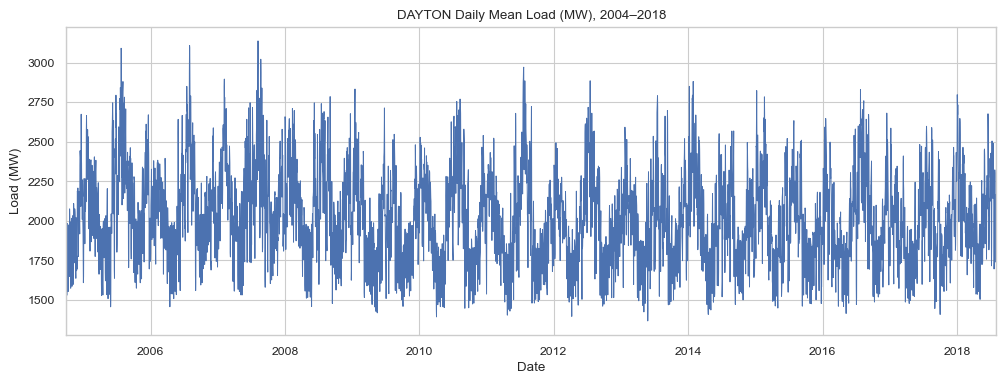

In [5]:
daily = df.set_index('Datetime')[TARGET].resample('D').mean()
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, linewidth=0.7)
ax.set_title('DAYTON Daily Mean Load (MW), 2004–2018')
ax.set_ylabel('Load (MW)')
ax.set_xlabel('Date')
plt.show()


**Distribution of the target.** Histogram with KDE overlay.

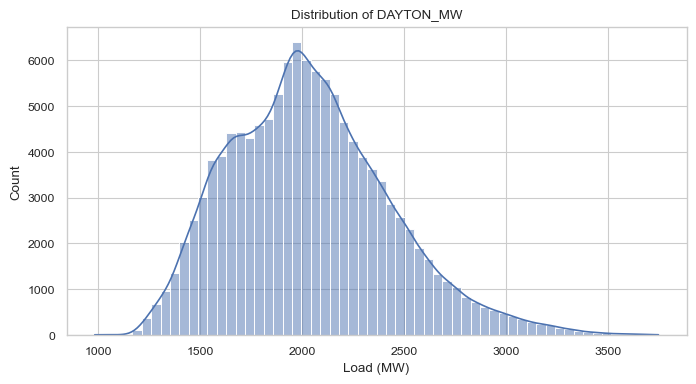

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax)
ax.set_title('Distribution of DAYTON_MW')
ax.set_xlabel('Load (MW)')
plt.show()


**Seasonality profiles.** Three boxplots showing how load varies by hour of day,
day of week, and month. These directly motivate the temporal features built in §2.4.


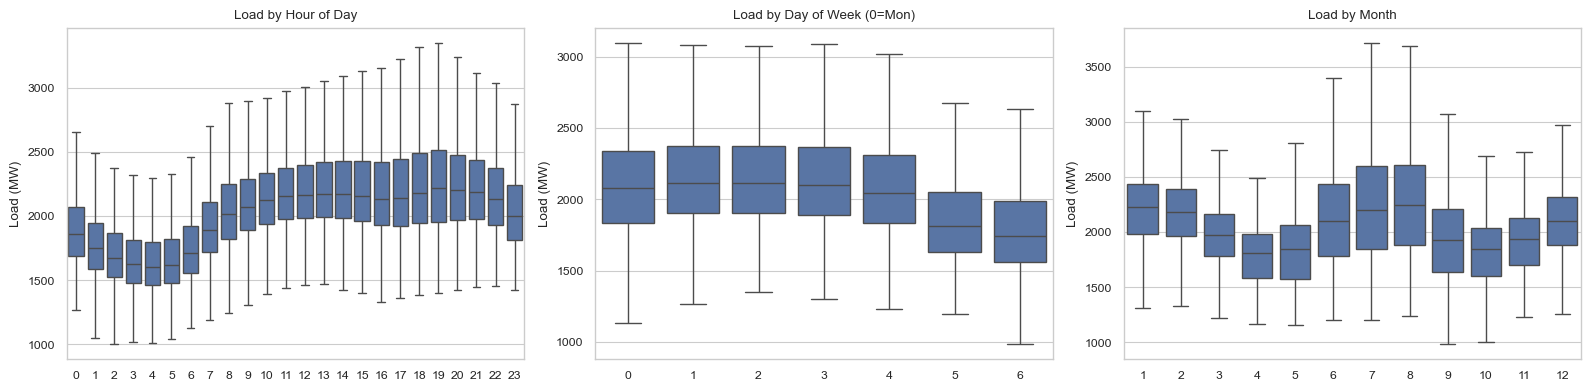

In [7]:
tmp = df.copy()
tmp['hour'] = tmp['Datetime'].dt.hour
tmp['dayofweek'] = tmp['Datetime'].dt.dayofweek
tmp['month'] = tmp['Datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=tmp, x='hour', y=TARGET, ax=axes[0], showfliers=False)
axes[0].set_title('Load by Hour of Day')
sns.boxplot(data=tmp, x='dayofweek', y=TARGET, ax=axes[1], showfliers=False)
axes[1].set_title('Load by Day of Week (0=Mon)')
sns.boxplot(data=tmp, x='month', y=TARGET, ax=axes[2], showfliers=False)
axes[2].set_title('Load by Month')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Load (MW)')
plt.tight_layout()
plt.show()


### 2.4 Feature Engineering

We build two feature families:

1. **Calendar features** — derivable from the timestamp alone, so they introduce no
   leakage. Cyclical (sine/cosine) encodings of `hour` and `dayofweek` are added
   alongside the raw integers; tree models don't strictly need them, but they give
   linear baselines a fair shot and add no risk.
2. **Lag and rolling-mean features** — `lag_24` (load 24 h ago, i.e., same hour
   yesterday), `lag_168` (same hour last week), and rolling means over the prior
   24 h and 168 h. Crucially, the rolling means are computed on the **shifted**
   series so the window for time *t* uses only data strictly before *t*. Without
   that `.shift(1)`, the rolling window would include the target itself and leak.

The first 168 rows have NaN lags and are dropped.


In [8]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add calendar, cyclical, lag, and rolling-mean features.

    The input frame must already be sorted ascending by Datetime.
    Returns a new frame with the engineered columns and NaN-leading rows dropped.
    """
    out = frame.copy()
    dt = out['Datetime']

    # Calendar features
    out['hour'] = dt.dt.hour
    out['dayofweek'] = dt.dt.dayofweek
    out['day'] = dt.dt.day
    out['month'] = dt.dt.month
    out['quarter'] = dt.dt.quarter
    out['dayofyear'] = dt.dt.dayofyear
    out['weekofyear'] = dt.dt.isocalendar().week.astype(int)
    out['year'] = dt.dt.year
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)

    # Cyclical encodings — wrap hour at 24 and dayofweek at 7
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)

    # Lag features — exact-hour lags
    out['lag_24'] = out[TARGET].shift(24)
    out['lag_168'] = out[TARGET].shift(168)

    # Rolling means computed on the SHIFTED series (window excludes time t itself)
    shifted = out[TARGET].shift(1)
    out['roll_mean_24'] = shifted.rolling(window=24).mean()
    out['roll_mean_168'] = shifted.rolling(window=168).mean()

    return out.dropna().reset_index(drop=True)


df_feat = engineer_features(df)
print('Rows after feature engineering:', len(df_feat))
print('Columns:', df_feat.columns.tolist())
df_feat.head()


Rows after feature engineering: 121103
Columns: ['Datetime', 'DAYTON_MW', 'hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168']


,Datetime,DAYTON_MW,hour,dayofweek,day,month,quarter,dayofyear,weekofyear,year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_24,lag_168,roll_mean_24,roll_mean_168
0,2004-10-08 01:00:00,1661.0,1,4,8,10,4,282,41,2004,0,0.258819,0.965926,-0.433884,-0.900969,1650.0,1621.0,1975.875000,1848.982143
1,2004-10-08 02:00:00,1585.0,2,4,8,10,4,282,41,2004,0,0.500000,0.866025,-0.433884,-0.900969,1584.0,1536.0,1976.333333,1849.220238
2,2004-10-08 03:00:00,1537.0,3,4,8,10,4,282,41,2004,0,0.707107,0.707107,-0.433884,-0.900969,1549.0,1500.0,1976.375000,1849.511905
3,2004-10-08 04:00:00,1529.0,4,4,8,10,4,282,41,2004,0,0.866025,0.500000,-0.433884,-0.900969,1534.0,1434.0,1975.875000,1849.732143
4,2004-10-08 05:00:00,1553.0,5,4,8,10,4,282,41,2004,0,0.965926,0.258819,-0.433884,-0.900969,1575.0,1489.0,1975.666667,1850.297619


### 2.5 Chronological Split (70 / 15 / 15)

Random splitting is **forbidden** for time series: a fold's training set could
contain timestamps later than its test set, which leaks future information backward
and produces optimistic — and dishonest — metrics. The split below slices the
sorted dataframe by index so that the validation window strictly follows the train
window and the test window strictly follows the validation window.


In [9]:
FEATURE_COLS = [
    'hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear',
    'year', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168',
]

n = len(df_feat)
i_train_end = int(n * 0.70)
i_val_end = int(n * 0.85)

train_df = df_feat.iloc[:i_train_end].copy()
val_df = df_feat.iloc[i_train_end:i_val_end].copy()
test_df = df_feat.iloc[i_val_end:].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val, y_val = val_df[FEATURE_COLS], val_df[TARGET]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET]

for name, frame in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(
        f'{name:5s} | n={len(frame):>6d} | '
        f"{frame['Datetime'].min()}  ->  {frame['Datetime'].max()}"
    )


Train | n= 84772 | 2004-10-08 01:00:00  ->  2014-06-11 01:00:00
Val   | n= 18165 | 2014-06-11 02:00:00  ->  2016-07-07 00:00:00
Test  | n= 18166 | 2016-07-07 01:00:00  ->  2018-08-03 00:00:00


## 3. Methods

### 3.1 Why `TimeSeriesSplit`?

Standard K-Fold cross-validation shuffles rows into folds, so a fold's training set
can — and routinely does — contain rows whose timestamps are *later* than rows in
its validation set. For autocorrelated time series this is a textbook leakage path:
the model effectively sees its own future during training, the CV score becomes
optimistic, and the chosen hyperparameters generalise poorly to genuinely future
data.

`sklearn.model_selection.TimeSeriesSplit` produces *expanding-window* folds where
each training window strictly precedes its validation window, mimicking how the
model would actually be deployed. We use 5 splits, applied **only on the training
set** — the validation and test sets remain fully untouched during tuning.


### 3.2 CV strategy & search spaces

In [10]:
tscv = TimeSeriesSplit(n_splits=5)
SCORING = 'neg_root_mean_squared_error'
N_ITER = 20  # RandomizedSearchCV draws per model — bump up for a more exhaustive search

rf_param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 1.0],
}

xgb_param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
}

lgb_param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 8, 12],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_samples': [10, 20, 40],
}


### 3.3 Tuning loop

In [11]:
def tune_model(estimator, param_dist, X_tr, y_tr, n_iter=N_ITER):
    """Run a TimeSeriesSplit-based RandomizedSearchCV on the training set.

    Returns the fitted RandomizedSearchCV object so the caller has access to
    best_estimator_, best_params_, and the full cv_results_.
    """
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring=SCORING,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
    )
    search.fit(X_tr, y_tr)
    return search


In [12]:
# Random Forest
rf_search = tune_model(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    X_train, y_train,
)
print('RF  best params:', rf_search.best_params_)
print(f'RF  best CV RMSE: {-rf_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF  best params: {'n_estimators': 600, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}
RF  best CV RMSE: 121.614


In [13]:
# XGBoost — fixed n_estimators during search; final fit uses early stopping on val
xgb_search = tune_model(
    xgb.XGBRegressor(
        random_state=RANDOM_STATE,
        tree_method='hist',
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    xgb_param_dist,
    X_train, y_train,
)
print('XGB best params:', xgb_search.best_params_)
print(f'XGB best CV RMSE: {-xgb_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGB best params: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
XGB best CV RMSE: 116.956


In [14]:
# LightGBM
lgb_search = tune_model(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    lgb_param_dist,
    X_train, y_train,
)
print('LGB best params:', lgb_search.best_params_)
print(f'LGB best CV RMSE: {-lgb_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
LGB best params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 40, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
LGB best CV RMSE: 115.763


### 3.4 Final fit

For RF the search's `best_estimator_` is already refit on the full training set.
For XGBoost and LightGBM we refit using the best hyperparameters but with
**early stopping on the validation set** — this prevents over-fitting at no risk
of leakage, since the validation window strictly follows training in time.


In [15]:
# RF — already refit on train
rf_model = rf_search.best_estimator_

# XGBoost — refit with early stopping on the validation set
xgb_best = {**xgb_search.best_params_}
xgb_model = xgb.XGBRegressor(
    **xgb_best,
    random_state=RANDOM_STATE,
    tree_method='hist',
    n_jobs=-1,
    objective='reg:squarederror',
    early_stopping_rounds=50,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# LightGBM — refit with early stopping on the validation set
lgb_best = {**lgb_search.best_params_}
lgb_model = lgb.LGBMRegressor(
    **lgb_best,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

print('All three models fit.')


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[793]	valid_0's l2: 9722.37
All three models fit.


## 4. Results

### 4.1 Test-set evaluation

In [16]:
def evaluate(name: str, model, X, y) -> dict:
    """Compute MAE, MAPE (in %), RMSE, MSE, and R² on (X, y)."""
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y, y_pred) * 100,
        'RMSE': np.sqrt(mse),
        'MSE': mse,
        'R2': r2_score(y, y_pred),
    }


results = pd.DataFrame([
    evaluate('RandomForest', rf_model, X_test, y_test),
    evaluate('XGBoost', xgb_model, X_test, y_test),
    evaluate('LightGBM', lgb_model, X_test, y_test),
]).sort_values('RMSE').reset_index(drop=True)

results.style.format({
    'MAE': '{:.2f}',
    'MAPE_%': '{:.2f}',
    'RMSE': '{:.2f}',
    'MSE': '{:.2f}',
    'R2': '{:.4f}',
})


,Model,MAE,MAPE_%,RMSE,MSE,R2
0,LightGBM,78.09,3.80,104.23,10863.05,0.9271
1,XGBoost,79.64,3.87,106.66,11376.21,0.9236
2,RandomForest,84.34,4.12,111.43,12416.24,0.9166


In [17]:
# Pick the best model by RMSE for the visualizations below
MODEL_BY_NAME = {'RandomForest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}
best_name = results.iloc[0]['Model']
best_model = MODEL_BY_NAME[best_name]
print('Best model on test RMSE:', best_name)


Best model on test RMSE: LightGBM


### 4.2 Actual vs Predicted (last 14 days of test set)

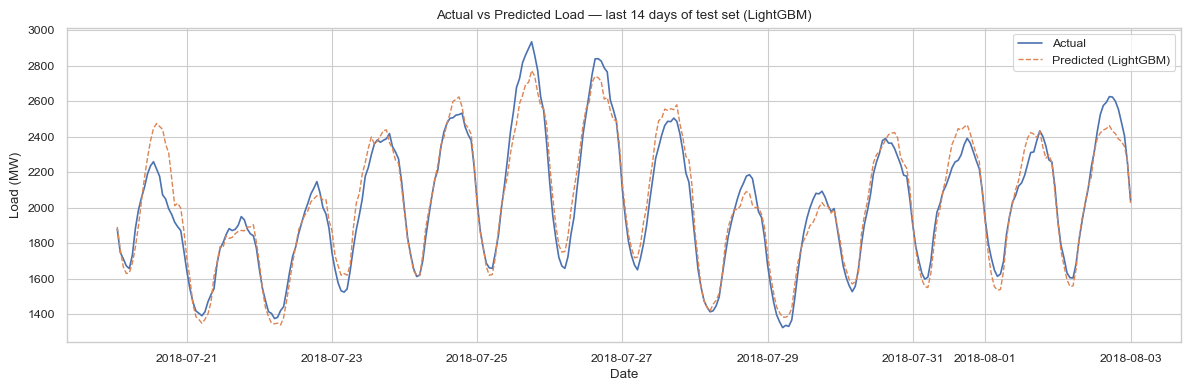

In [18]:
y_pred_test = best_model.predict(X_test)
n_hours = 24 * 14
tail = test_df.iloc[-n_hours:].copy()
tail['pred'] = y_pred_test[-n_hours:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tail['Datetime'], tail[TARGET], label='Actual', linewidth=1.2)
ax.plot(tail['Datetime'], tail['pred'], label=f'Predicted ({best_name})',
        linewidth=1.0, linestyle='--')
ax.set_title(f'Actual vs Predicted Load — last 14 days of test set ({best_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()


### 4.3 Feature Importance (best model, top 15)

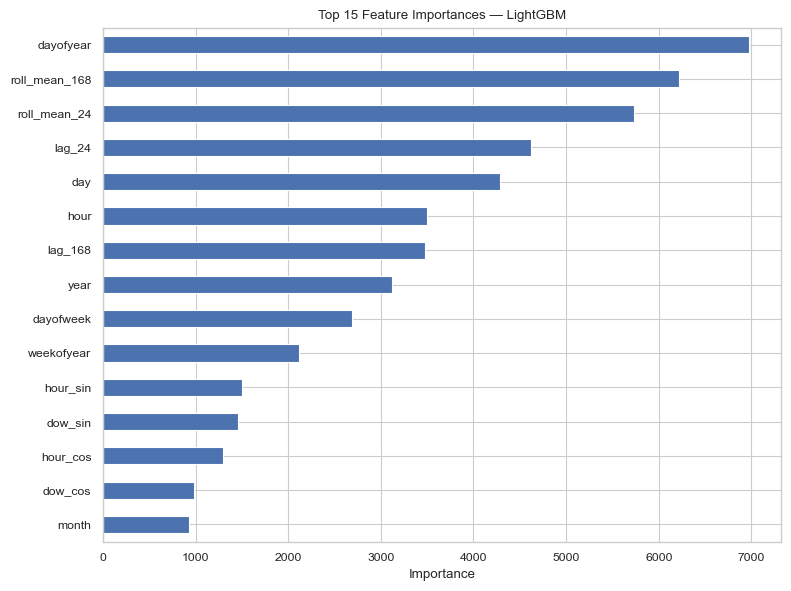

In [19]:
importances = pd.Series(
    best_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title(f'Top 15 Feature Importances — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


## 5. Discussion

*(Expand these bullets into prose for the report.)*

- **Comparative performance.** Compare RF / XGBoost / LightGBM on the metrics table
  above. Note where each one wins (typically: gradient-boosted models on RMSE/MAPE,
  RF as a robust baseline).
- **Feature importance interpretation.** `lag_24` and `lag_168` are expected to
  dominate, reflecting the strong daily and weekly seasonality already visible in
  the EDA boxplots. Discuss what this implies about the target's autocorrelation
  structure.
- **Limitations.** No exogenous regressors were used: in particular, weather
  (temperature, humidity, cloud cover) drives a large fraction of load variance and
  is the standard next addition in academic and industrial work. Holiday calendars
  are also absent.
- **Future work.** (i) Add weather features from a service such as NOAA or
  Meteostat. (ii) Compare against classical baselines (Prophet, SARIMA) and against
  deep models (LSTM, N-BEATS, Temporal Fusion Transformer). (iii) Move from
  one-step to multi-step forecasting (24 h ahead) and re-evaluate.


## 6. Conclusion

*(Stub — write a 1-paragraph wrap-up summarising headline numbers, the value of
lag features, and the importance of strict temporal validation.)*

## References

*(Add IEEE-style references: PJM dataset citation, original papers for
RandomForest [Breiman, 2001], XGBoost [Chen & Guestrin, 2016], LightGBM
[Ke et al., 2017], and standard load-forecasting surveys.)*
